## Predicting Chronic Heart Failure after Myocardial Infarction

### Clinical Use Case

Patients admitted with **myocardial infarction (MI)** are at risk of
developing a range of complications, including **chronic heart failure (CHF)**.

Chronic heart failure is a serious condition that can significantly impair
quality of life and is associated with increased morbidity and mortality.

Following an acute myocardial infarction, some patients recover without
long-term consequences, while others develop progressive cardiac dysfunction
leading to heart failure.

Early identification of patients at risk of developing chronic heart failure
is challenging, even for experienced clinicians, but highly relevant for
optimizing treatment and improving long-term outcomes.

---

**Goal of this analysis:**

Build a machine learning model that predicts whether a patient will
develop **chronic heart failure** during hospitalization.

You can download the dataset of myocardial infarction complications from the University of Leicester here:
https://figshare.le.ac.uk/ndownloader/files/23581310

---

### About the Dataset

This dataset contains clinical information about patients admitted with
myocardial infarction and was designed to evaluate real-world medical
prediction problems.

Variables include:

- demographic data
- medical history
- ECG findings
- laboratory values
- treatment information

Possible complications are stored in the target variables.

In this notebook, we focus on predicting:

**Chronic Heart Failure**

Additional information about the dataset, including variable descriptions, can be found here:
https://doi.org/10.25392/leicester.data.12045261

---

**Important methodological aspect**

The dataset allows prediction at **different time points during the hospital stay**:

1. At admission
2. After 24 hours
3. After 48 hours
4. After 72 hours

Depending on the chosen time point, **different variables are available**.

For this exercise, you must **decide on one time point** and
**adapt your feature selection accordingly**.

For example:

- If you predict at **admission**, you may only use variables available at admission
- Later time points allow more information, but also introduce the risk of **data leakage**

This reflects a key challenge in clinical machine learning:

> Predictions must be based only on information that is available at the time the decision is made.

---

**Potential clinical use:**

- early identification of patients at risk of chronic heart failure
- timely initiation of preventive or therapeutic interventions
- improved long-term management and follow-up planning



### Your Tasks

- Load and explore the dataset to understand its structure and contents
- Decide at which time point you want to predict the ventricular fibrillation (target variable =  "FIBR_JELUD") \
  Adjust your feature selection accordingly
- Prepare the data for machine learning
- Train and compare different models (e.g. Logistic Regression, Random Forest, XGB)
- Evaluate model performance using appropriate metrics
- Interpret your results and reflect on their clinical relevance

In [516]:
# Import bia-bob as a helpful Python & Medical AI expert
'''from bia_bob import bob
import os

bob.initialize(
    endpoint='https://kiara.sc.uni-leipzig.de/api/v1',
    model="vllm-llama-4-scout-17b-16e-instruct",
    system_prompt=os.getenv('SYSTEM_PROMPT_MEDICAL_AI')
)'''

'from bia_bob import bob\nimport os\n\nbob.initialize(\n    endpoint=\'https://kiara.sc.uni-leipzig.de/api/v1\',\n    model="vllm-llama-4-scout-17b-16e-instruct",\n    system_prompt=os.getenv(\'SYSTEM_PROMPT_MEDICAL_AI\')\n)'

In [517]:
# %bob Who are you? Just one sentence!

### NOTE
In this notebook we focus on predicting:

**Chronic heart failure (ZSN) at the time of admission to the hospital**

Therefore, we use all input columns (2-112) except _93, 94, 95, 100, 101, 102, 103, 104, 105_.

## Step 1: Load and inspect the data

In [518]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

import shap


In [519]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)

In [520]:
# load the dataset
df = pd.read_csv('Myocardial_infarction_complications_Database.csv')

In [521]:
df.head()

,ID,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr_11,nr_01,nr_02,nr_03,nr_04,nr_07,nr_08,np_01,np_04,np_05,np_07,np_08,np_09,np_10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_KBRIG,D_AD_KBRIG,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,GIPO_K,K_BLOOD,GIPER_NA,NA_BLOOD,ALT_BLOOD,AST_BLOOD,KFK_BLOOD,L_BLOOD,ROE,TIME_B_S,R_AB_1_n,R_AB_2_n,R_AB_3_n,NA_KB,NOT_NA_KB,LID_KB,NITR_S,NA_R_1_n,NA_R_2_n,NA_R_3_n,NOT_NA_1_n,NOT_NA_2_n,NOT_NA_3_n,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,FIBR_PREDS,PREDS_TAH,JELUD_TAH,FIBR_JELUD,A_V_BLOK,OTEK_LANC,RAZRIV,DRESSLER,ZSN,REC_IM,P_IM_STEN,LET_IS
0,1,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,180.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.7,0.0,138.0,NaN,NaN,NaN,8.0,16.0,4.0,0.0,0.0,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,120.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.5,0.0,132.0,0.38,0.18,NaN,7.8,3.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,100.0,180.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,132.0,0.30,0.11,NaN,10.8,NaN,3.0,3.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,3.0,2.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,120.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.9,0.0,146.0,0.75,0.37,NaN,NaN,NaN,2.0,0.0,0.0,1.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0,0,0,0,0,0,0,0,1,0,0,0
4,5,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,190.0,100.0,160.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.5,0.0,132.0,0.45,0.22,NaN,8.3,NaN,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0,0,0,0,0,0,0,0,0,0,0,0


In [522]:
# Get dataset size
print("Dataset contains {} rows".format(df.shape[0]))
print("Dataset contains {} columns".format(df.shape[1]))

Dataset contains 1700 rows
Dataset contains 124 columns


In [523]:
# Get summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Columns: 124 entries, ID to LET_IS
dtypes: float64(110), int64(14)
memory usage: 1.6 MB


In [524]:
# Set patient ID as index (keep column as well)
df = df.set_index("ID", drop=False)

In [525]:
# Define target variable
target = "ZSN"

In [526]:
# Feature Selection (Admission)

# Select predictor columns (2–112)
feature_cols = df.columns[1:112]

# Indices to remove (relative to original df)
drop_idx = [92, 93, 94, 99, 100, 101, 102, 103, 104]

cols_to_remove = df.columns[drop_idx]

# Final feature list
feature_cols = feature_cols.drop(cols_to_remove)

# Keep only relevant columns in df
# IMPORTANT: keep target + selected features
df = df[feature_cols.tolist() + [target]]

# Optional: rename target for clarity
df = df.rename(columns={target: "target"})

In [527]:
# Get new size of the dataset
df.shape

(1700, 103)

In [528]:
df.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,IBS_NASL,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr_11,nr_01,nr_02,nr_03,nr_04,nr_07,nr_08,np_01,np_04,np_05,np_07,np_08,np_09,np_10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_KBRIG,D_AD_KBRIG,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,GIPO_K,K_BLOOD,GIPER_NA,NA_BLOOD,ALT_BLOOD,AST_BLOOD,KFK_BLOOD,L_BLOOD,ROE,TIME_B_S,NA_KB,NOT_NA_KB,LID_KB,NITR_S,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,target
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,77.0,1,2.0,1.0,1.0,2.0,NaN,3.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,180.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.7,0.0,138.0,NaN,NaN,NaN,8.0,16.0,4.0,NaN,NaN,NaN,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
2,55.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,120.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.5,0.0,132.0,0.38,0.18,NaN,7.8,3.0,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0
3,52.0,1,0.0,0.0,0.0,2.0,NaN,2.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150.0,100.0,180.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,132.0,0.30,0.11,NaN,10.8,NaN,3.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0
4,68.0,0,0.0,0.0,0.0,2.0,NaN,2.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,120.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.9,0.0,146.0,0.75,0.37,NaN,NaN,NaN,2.0,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1
5,60.0,1,0.0,0.0,0.0,2.0,NaN,3.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,190.0,100.0,160.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.5,0.0,132.0,0.45,0.22,NaN,8.3,NaN,9.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0


In [529]:
# Detect feature types

binary_features = []
categorical_features = []
continuous_features = []

for col in feature_cols:

    n_unique = df[col].nunique(dropna=True)

    # Binary: exactly 2 unique values
    if n_unique == 2:
        binary_features.append(col)

    # Categorical: few unique values (but not binary)
    elif n_unique < 10:
        categorical_features.append(col)

    # Continuous: many unique values
    else:
        continuous_features.append(col)

In [530]:
# Assign data types
df[binary_features] = df[binary_features].astype("category")
df[categorical_features] = df[categorical_features].astype("category")

In [531]:
# Overview of 
print("Binary features:", len(binary_features))
print("Categorical features:", len(categorical_features))
print("Continuous features:", len(continuous_features))

Binary features: 78
Categorical features: 13
Continuous features: 11


In [532]:
df.dtypes.value_counts()

category    77
float64     11
category     6
category     2
category     1
category     1
category     1
category     1
category     1
category     1
int64        1
Name: count, dtype: int64

In [533]:
# Summary statistics for numeric columns
df.describe(include=['int', 'float']).T

,count,mean,std,min,25%,50%,75%,max
AGE,1692.0,61.856974,11.259936,26.00,54.00,63.00,70.00,92.00
S_AD_KBRIG,624.0,136.907051,34.997835,0.00,120.00,140.00,160.00,260.00
D_AD_KBRIG,624.0,81.394231,19.745045,0.00,70.00,80.00,90.00,190.00
S_AD_ORIT,1433.0,134.588276,31.348388,0.00,120.00,130.00,150.00,260.00
D_AD_ORIT,1433.0,82.749477,18.321063,0.00,80.00,80.00,90.00,190.00
K_BLOOD,1329.0,4.191422,0.754076,2.30,3.70,4.10,4.60,8.20
NA_BLOOD,1325.0,136.550943,6.512120,117.00,133.00,136.00,140.00,169.00
ALT_BLOOD,1416.0,0.481455,0.387261,0.03,0.23,0.38,0.61,3.00
AST_BLOOD,1415.0,0.263717,0.201802,0.04,0.15,0.22,0.33,2.15
L_BLOOD,1575.0,8.782914,3.400557,2.00,6.40,8.00,10.45,27.90


In [534]:
# Summary statistics for categorical columns
df.describe(include="category").T

,count,unique,top,freq
SEX,1700.0,2.0,1.0,1065.0
INF_ANAM,1696.0,4.0,0.0,1060.0
STENOK_AN,1594.0,7.0,0.0,661.0
FK_STENOK,1627.0,5.0,2.0,854.0
IBS_POST,1649.0,3.0,2.0,683.0
IBS_NASL,72.0,2.0,0.0,45.0
GB,1691.0,4.0,2.0,880.0
SIM_GIPERT,1692.0,2.0,0.0,1635.0
DLIT_AG,1452.0,8.0,0.0,551.0
ZSN_A,1646.0,5.0,0.0,1468.0


## Step 2: Exploratory Data Analysis (EDA)

Before training machine learning models, it is important to understand
the structure of the dataset.

In this section we explore:

- distribution of target variable
- missing values
- class imbalance

In [535]:
df['target'].value_counts()

target
0    1306
1     394
Name: count, dtype: int64

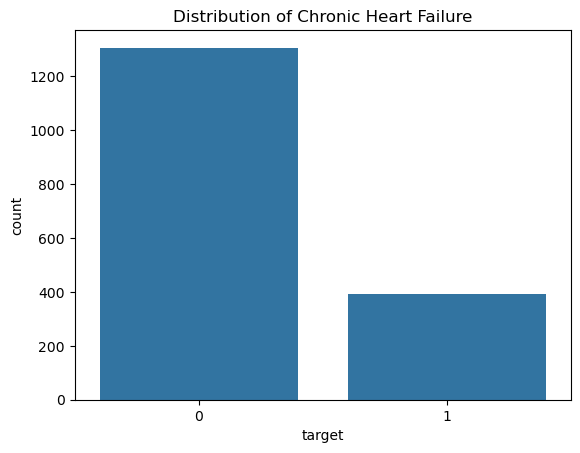

In [536]:
sns.countplot(x='target', data=df)
plt.title("Distribution of Chronic Heart Failure")
plt.show()

-> **Class Imbalance**

Chronic Heart Failure is a **rare event** in this dataset.

This creates a **class imbalance problem**, meaning that most patients
belong to the negative class.

This can lead to biased models that simply predict the majority class.

To address this issue we will later use:

- class weights
- adjusted thresholds
- ROC-AUC evaluation

### Visualization of prediction variables

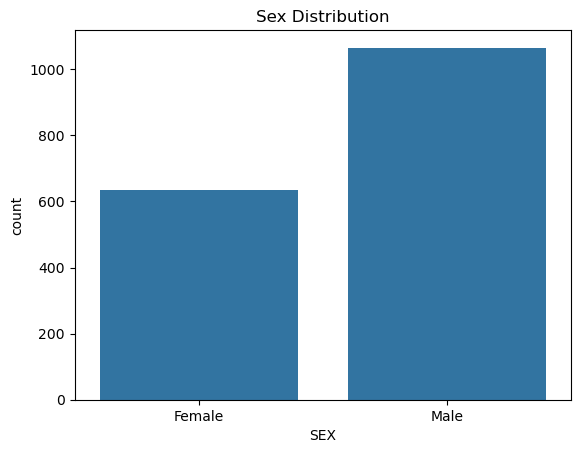

In [537]:
# NOTE: 0 - female, 1 - male
sns.countplot(x=df['SEX'].map({0: "Female", 1: "Male"}), data=df)
plt.title("Sex Distribution")
plt.show()

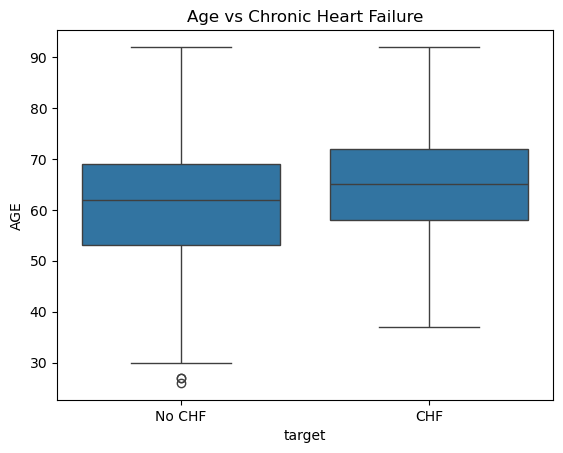

In [538]:
sns.boxplot(x=df['target'].map({0: "No CHF", 1: "CHF"}), y="AGE", data=df)
plt.title("Age vs Chronic Heart Failure")
plt.show()

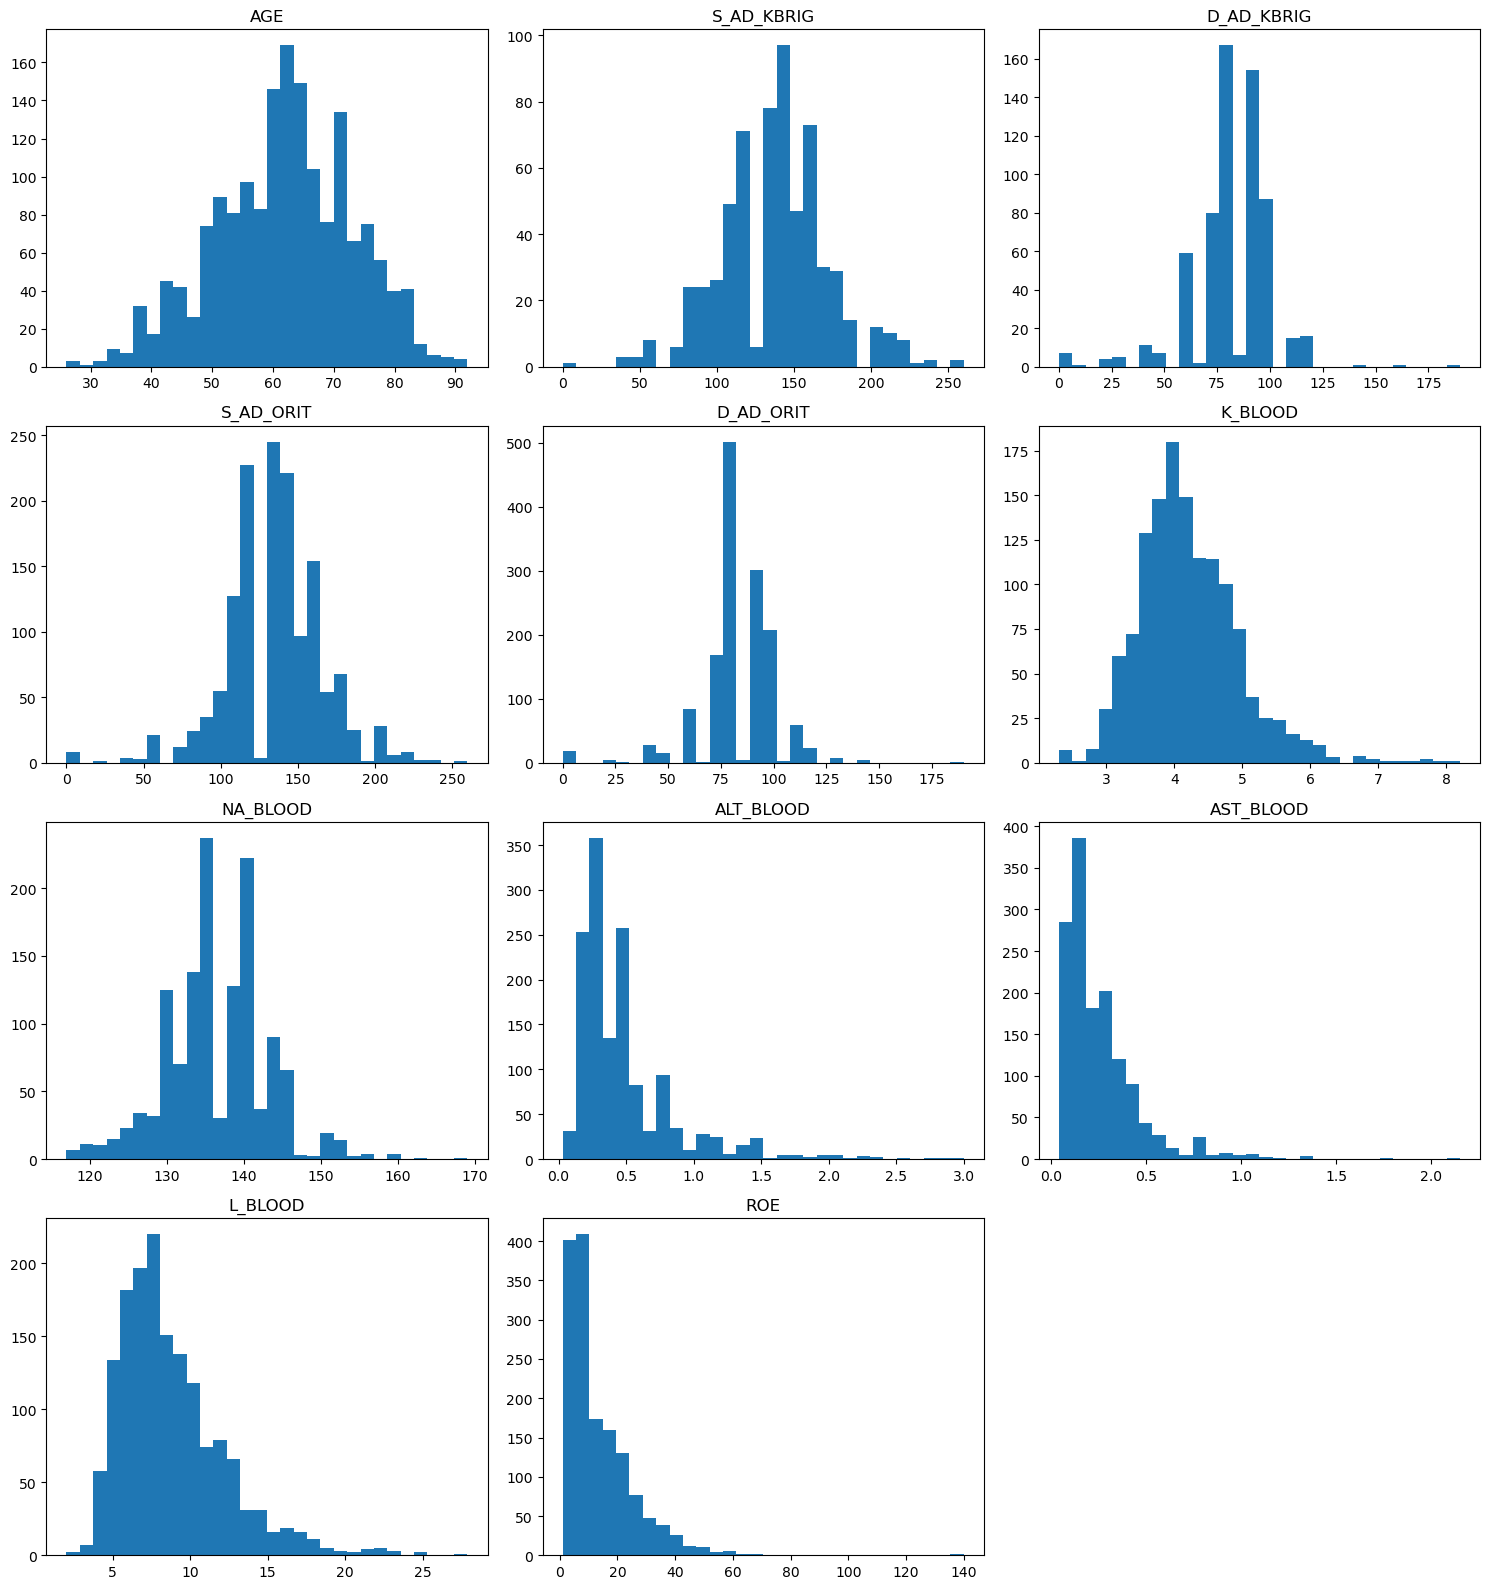

In [539]:
import matplotlib.pyplot as plt
import math

# number of plots
n_features = len(continuous_features)

# define grid size
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

# flatten axes (important!)
axes = axes.flatten()

# plot each feature
for i, col in enumerate(continuous_features):

    axes[i].hist(df[col].dropna(), bins=30)
    axes[i].set_title(col)

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

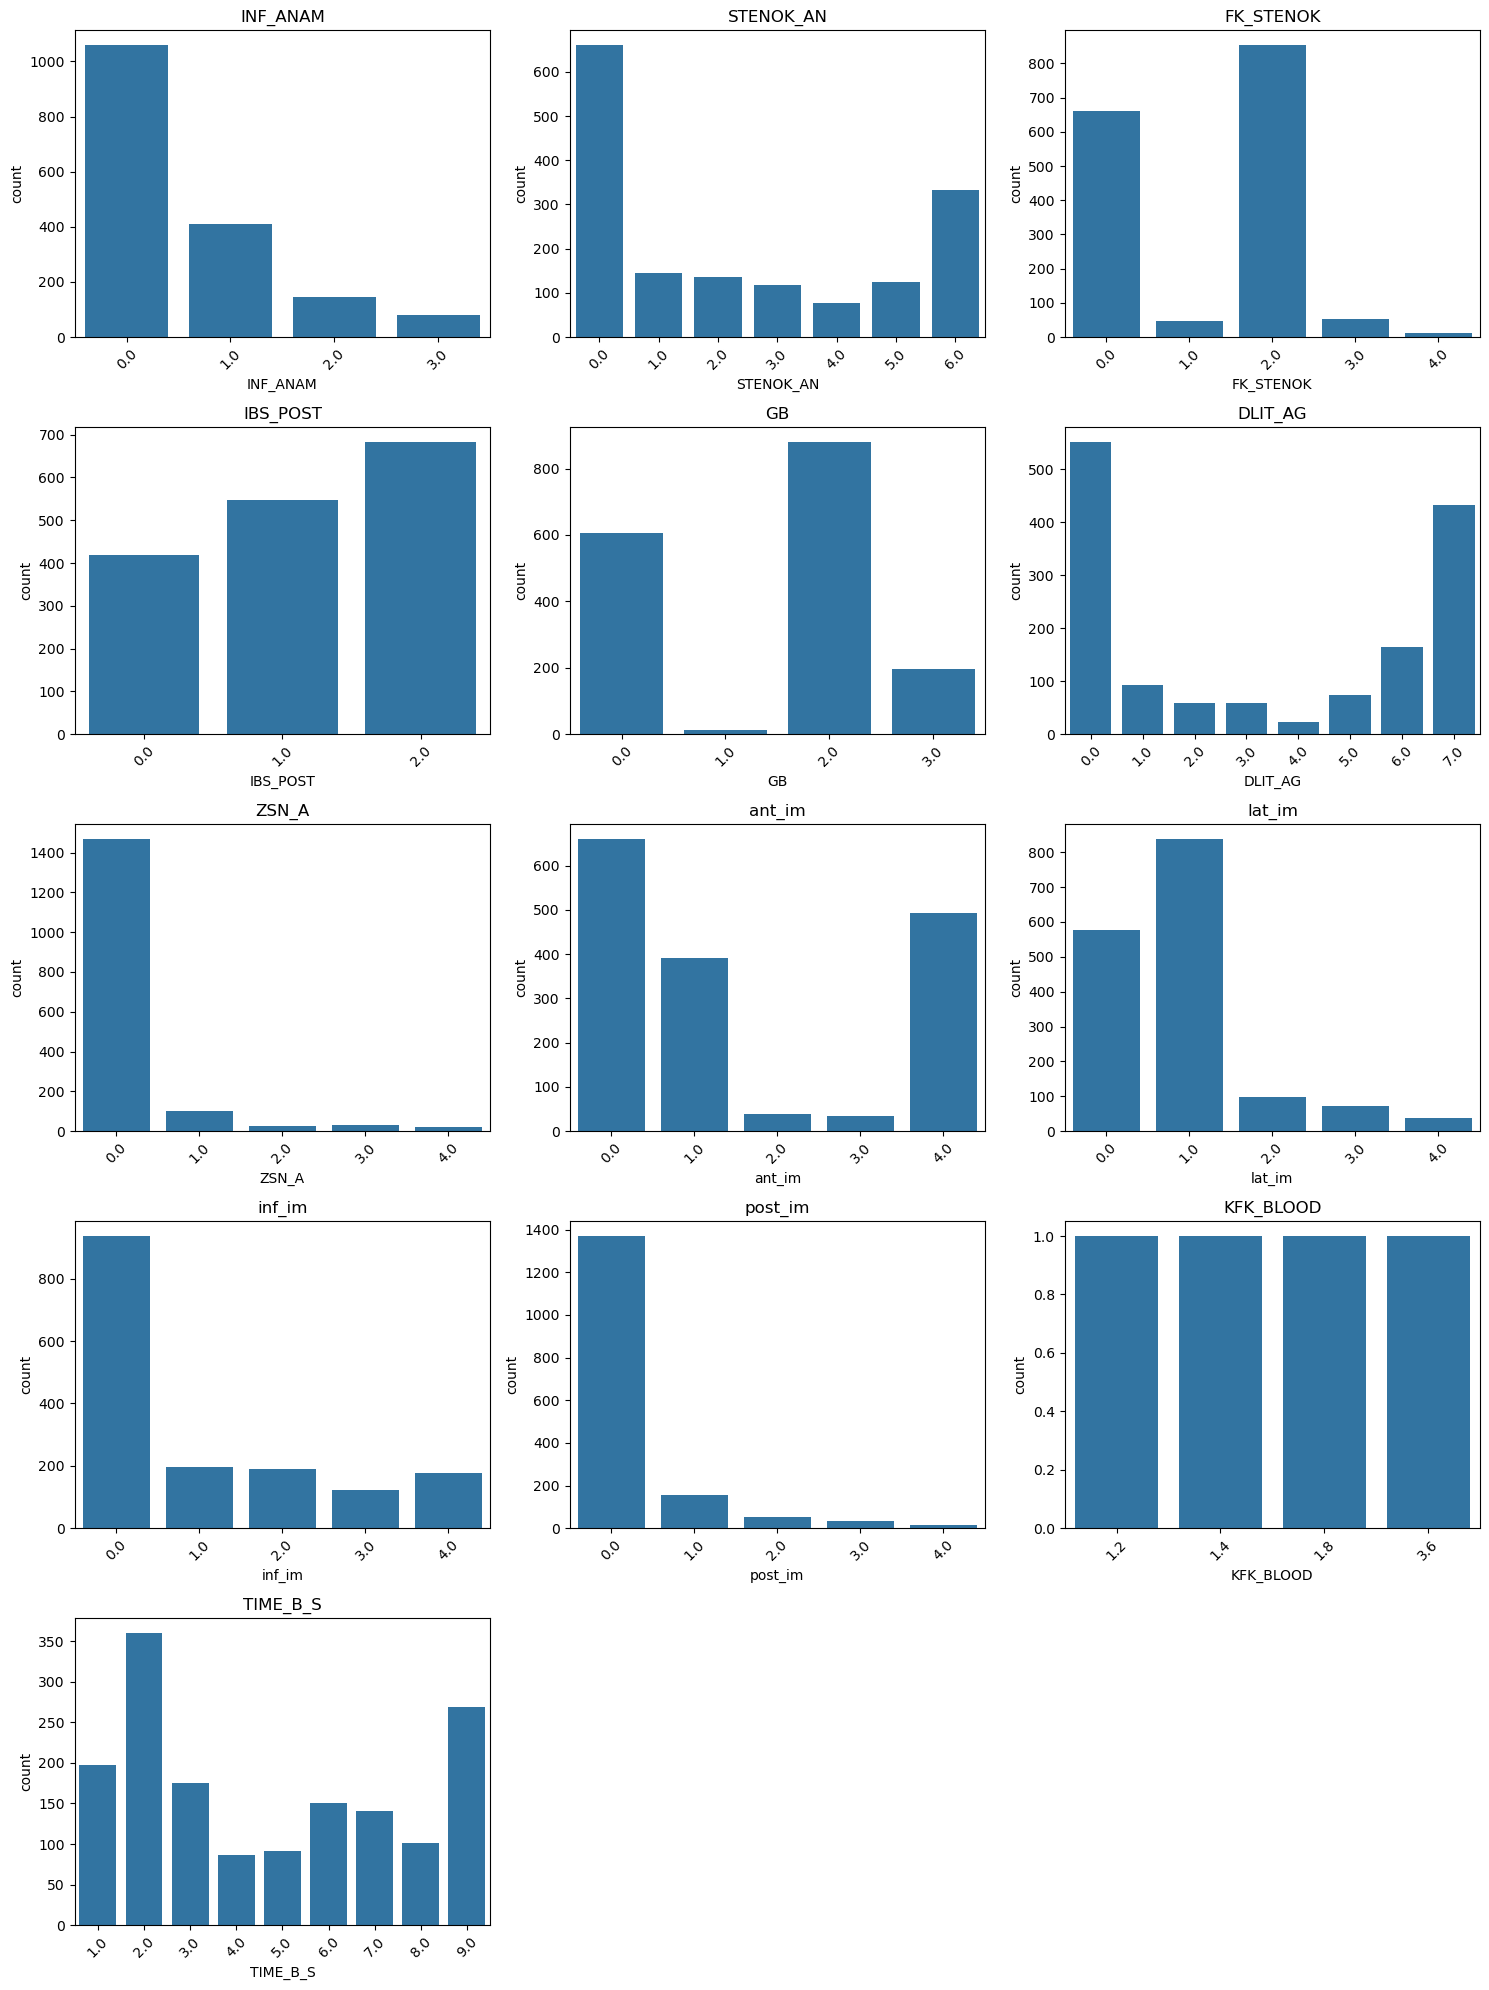

In [540]:
# number of plots
n_features = len(categorical_features)

# grid size
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

# plot each categorical feature
for i, col in enumerate(categorical_features):

    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Check for missing values

In [541]:
# Get table with missing value counts and percentage for each feature
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "missing_percent", ascending=False
)

missing_summary.head(25)

,missing_count,missing_percent
KFK_BLOOD,1696,99.764706
IBS_NASL,1628,95.764706
D_AD_KBRIG,1076,63.294118
S_AD_KBRIG,1076,63.294118
NOT_NA_KB,686,40.352941
LID_KB,677,39.823529
NA_KB,657,38.647059
NA_BLOOD,375,22.058824
GIPER_NA,375,22.058824
K_BLOOD,371,21.823529


### Correlation Analysis

We inspect correlations between continuous variables.

Highly correlated variables often measure similar physiological processes.

Tree-based models such as Random Forest and XGBoost can handle correlated
predictors relatively well, therefore we do not automatically remove them.

In [542]:
# Calculate correlation matrix for numerical features
corr_matrix = df.select_dtypes(include=[np.number]).corr()

# Show correlation table
corr_matrix

,AGE,S_AD_KBRIG,D_AD_KBRIG,S_AD_ORIT,D_AD_ORIT,K_BLOOD,NA_BLOOD,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,target
AGE,1.000000,0.095658,-0.022013,0.043821,-0.049489,-0.002999,0.031139,-0.104688,-0.053533,0.003120,0.214393,0.146107
S_AD_KBRIG,0.095658,1.000000,0.844144,0.611365,0.555501,-0.004314,-0.008899,-0.045470,-0.083252,-0.172723,0.005249,0.072490
D_AD_KBRIG,-0.022013,0.844144,1.000000,0.543048,0.555960,-0.011671,0.012838,-0.056683,-0.057641,-0.125900,-0.022010,0.059376
S_AD_ORIT,0.043821,0.611365,0.543048,1.000000,0.861266,0.030007,0.042669,-0.102709,-0.103231,-0.144040,0.040766,0.062360
D_AD_ORIT,-0.049489,0.555501,0.555960,0.861266,1.000000,0.011964,0.020672,-0.059277,-0.075661,-0.155752,0.011588,0.052345
K_BLOOD,-0.002999,-0.004314,-0.011671,0.030007,0.011964,1.000000,0.300430,0.023802,0.051519,0.012584,0.009055,-0.024080
NA_BLOOD,0.031139,-0.008899,0.012838,0.042669,0.020672,0.300430,1.000000,-0.005731,-0.022231,0.015816,-0.013838,0.012107
ALT_BLOOD,-0.104688,-0.045470,-0.056683,-0.102709,-0.059277,0.023802,-0.005731,1.000000,0.519449,0.044393,-0.007868,0.053766
AST_BLOOD,-0.053533,-0.083252,-0.057641,-0.103231,-0.075661,0.051519,-0.022231,0.519449,1.000000,0.077660,-0.030673,0.032433
L_BLOOD,0.003120,-0.172723,-0.125900,-0.144040,-0.155752,0.012584,0.015816,0.044393,0.077660,1.000000,0.005169,-0.004620


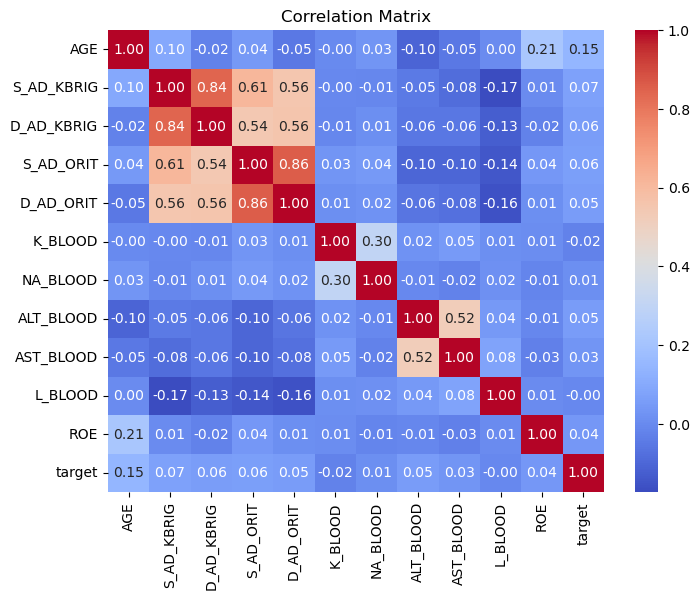

In [543]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Step 3: Feature preprocessing

Before training machine learning models we need to define which variables
should be used as predictors.

The dataset contains more than 100 potential input variables.

However, not all variables are suitable for the prediction of .

We apply three feature selection steps:

1. Remove identifiers and target variables
2. Remove variables with excessive missing values
3. Inspect correlations between continuous variables

Important note:

Tree-based models such as Random Forest and XGBoost are generally robust
to correlated predictors, therefore we usually **do not automatically remove
correlated features** unless they are redundant.

### Handling Missing Data

Clinical datasets often contain missing values because:

- laboratory tests may not be performed
- documentation may be incomplete
- measurements may not be available at admission

Therefore, we apply different strategies depending on the variable type:

- All variables:
  Removed if more than 30% of values are missing

In [544]:
missing_percent = df.isna().mean()

# Keep continuous variables with <= 30% missing
continuous_keep = [
    col for col in continuous_features
    if missing_percent[col] <= 0.3
]

# Keep categorical/binary only if no missing values
categorical_keep = [
    col for col in categorical_features
    if missing_percent[col] <= 0.3
]

binary_keep = [
    col for col in binary_features
    if missing_percent[col] <= 0.3
]

# Combine selected features
selected_features = continuous_keep + categorical_keep + binary_keep + ["target"]
df = df[selected_features]

In [545]:
print("After removing binary and categorical features with missing values and continuous features with more than 30% missing values, there are {} features left.".format(len(selected_features) - 1))

After removing binary and categorical features with missing values and continuous features with more than 30% missing values, there are 95 features left.


In [546]:
# Split features and target
X = df.drop(columns="target")
y = df["target"]

#### Train-Test Split

To evaluate the model properly we split the dataset into:

- training data – used to train the models
- test data – used to evaluate performance

We use **stratified sampling** to preserve the class distribution.

In [547]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Preprocessing pipeline

- Data imputation
- Standardization

In [548]:
# Continuous features
continuous_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # fill missing values
    ("scaler", StandardScaler())                     # normalize values
])

# Categorical + Binary features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))  # fill missing values
])

In [549]:
# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", continuous_pipeline, continuous_keep),
    ("cat", categorical_pipeline, categorical_keep + binary_keep)
])

**Encoding of categorical features** is not necessary for this dataset, because all features are already encoded.

## Step 4: Modeling

We compare three different machine learning algorithms:

**Logistic Regression**
- simple baseline model
- interpretable

**Random Forest**
- ensemble of decision trees
- captures non-linear relationships

**XGBoost**
- gradient boosting algorithm
- often performs very well on tabular data

In [550]:
logreg_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced"))
])

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ))
])

#### Hyperparameter Tuning

Machine learning models have parameters that must be chosen before
training.

In [551]:
logreg_grid = {
"model__C":[0.01,0.1,1,10]
}

In [552]:
rf_grid = {

"model__n_estimators":[100,300],
"model__max_depth":[5,10,None],
"model__min_samples_split":[2,5]

}

In [553]:
xgb_grid = {

"model__n_estimators":[100,300],
"model__max_depth":[3,6],
"model__learning_rate":[0.01,0.1]

}

In [554]:
print("Columns in X:")
print(X.columns.tolist())

Columns in X:
['AGE', 'S_AD_ORIT', 'D_AD_ORIT', 'K_BLOOD', 'NA_BLOOD', 'ALT_BLOOD', 'AST_BLOOD', 'L_BLOOD', 'ROE', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'DLIT_AG', 'ZSN_A', 'ant_im', 'lat_im', 'inf_im', 'post_im', 'TIME_B_S', 'SEX', 'SIM_GIPERT', 'nr_11', 'nr_01', 'nr_02', 'nr_03', 'nr_04', 'nr_07', 'nr_08', 'np_01', 'np_04', 'np_05', 'np_07', 'np_08', 'np_09', 'np_10', 'endocr_01', 'endocr_02', 'endocr_03', 'zab_leg_01', 'zab_leg_02', 'zab_leg_03', 'zab_leg_04', 'zab_leg_06', 'O_L_POST', 'K_SH_POST', 'MP_TP_POST', 'SVT_POST', 'GT_POST', 'FIB_G_POST', 'IM_PG_P', 'ritm_ecg_p_01', 'ritm_ecg_p_02', 'ritm_ecg_p_04', 'ritm_ecg_p_06', 'ritm_ecg_p_07', 'ritm_ecg_p_08', 'n_r_ecg_p_01', 'n_r_ecg_p_02', 'n_r_ecg_p_03', 'n_r_ecg_p_04', 'n_r_ecg_p_05', 'n_r_ecg_p_06', 'n_r_ecg_p_08', 'n_r_ecg_p_09', 'n_r_ecg_p_10', 'n_p_ecg_p_01', 'n_p_ecg_p_03', 'n_p_ecg_p_04', 'n_p_ecg_p_05', 'n_p_ecg_p_06', 'n_p_ecg_p_07', 'n_p_ecg_p_08', 'n_p_ecg_p_09', 'n_p_ecg_p_10', 'n_p_ecg_p_11', 'n_p_ec

In [555]:
print("Continuous features:")
print(continuous_features)

Continuous features:
['AGE', 'S_AD_KBRIG', 'D_AD_KBRIG', 'S_AD_ORIT', 'D_AD_ORIT', 'K_BLOOD', 'NA_BLOOD', 'ALT_BLOOD', 'AST_BLOOD', 'L_BLOOD', 'ROE']


#### Grid Search

GridSearchCV automatically tests multiple parameter combinations and
selects the best configuration based on cross-validation performance.

In [556]:
logreg_search = GridSearchCV(
    logreg_pipeline,
    logreg_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

logreg_search.fit(X_train,y_train)

,estimator,Pipeline(step..._iter=2000))])
,param_grid,"{'model__C': [0.01, 0.1, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [557]:
rf_search = GridSearchCV(
rf_pipeline,
rf_grid,
cv=5,
scoring="roc_auc",
n_jobs=-1
)

rf_search.fit(X_train,y_train)

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 300]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [558]:
xgb_search = GridSearchCV(
xgb_pipeline,
xgb_grid,
cv=5,
scoring="roc_auc",
n_jobs=-1
)

xgb_search.fit(X_train,y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 6], 'model__n_estimators': [100, 300]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


## Step 5: Model Evaluation

In [559]:
models = {
    "Logistic Regression": logreg_search.best_estimator_,
    "Random Forest": rf_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

results = []

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

    report = classification_report(y_test, y_pred_optimal, output_dict=True)

    results.append({
        "Model": name,
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Optimal_Threshold": optimal_threshold,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1_score": report["1"]["f1-score"]
    })

results_df = pd.DataFrame(results).round(3)
results_df

,Model,ROC_AUC,Optimal_Threshold,Precision,Recall,F1_score
0,Logistic Regression,0.660,0.452,0.344,0.696,0.460
1,Random Forest,0.711,0.415,0.320,0.911,0.474
2,XGBoost,0.737,0.440,0.361,0.709,0.479


### Confusion Matrix

The confusion matrix shows the number of:

* True Positives
* True Negatives
* False Positives
* False Negatives

In clinical applications, **false negatives may be particularly critical**,
because a high-risk patient might be missed.

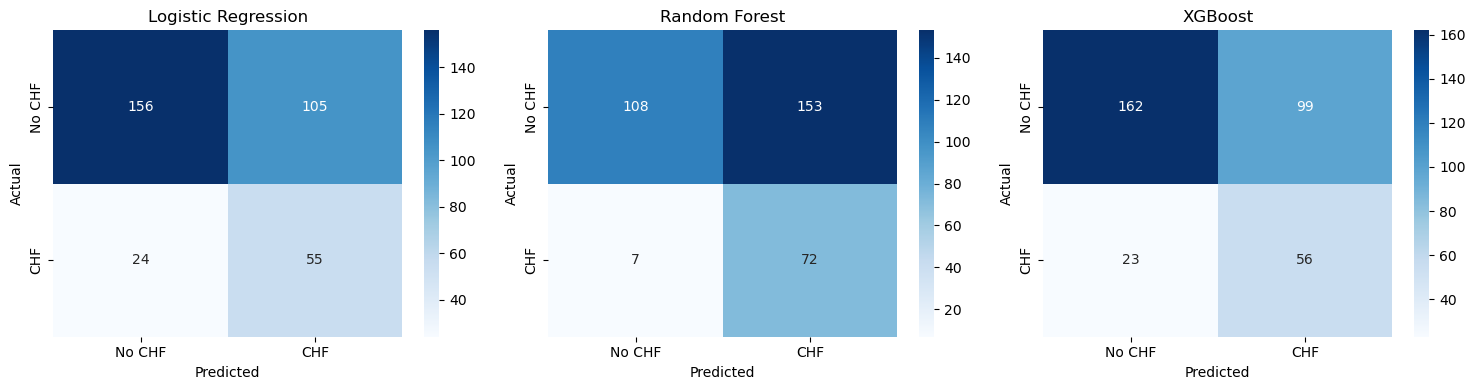

In [560]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, (name, model) in zip(axes, models.items()):

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    y_pred = (y_prob >= optimal_threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No CHF","CHF"],
        yticklabels=["No CHF","CHF"],
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

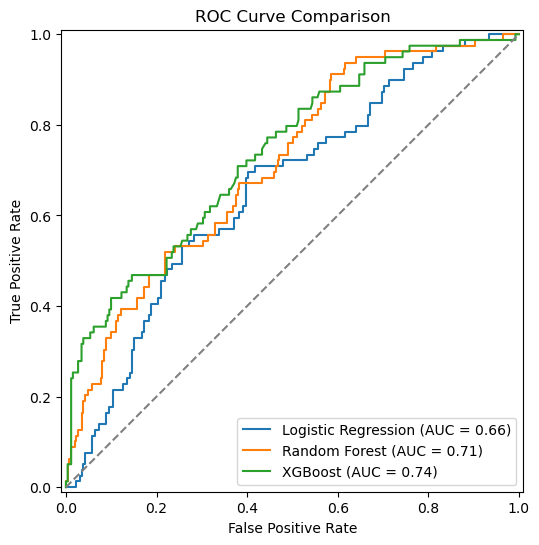

In [561]:
fig, ax = plt.subplots(figsize=(7,6))

for name, model in models.items():

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=name
    )

# random classifier baseline
ax.plot([0,1], [0,1], linestyle="--", color="grey")

ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

plt.legend()
plt.show()

## Optional: Model Explainability

Machine learning models are often considered "black boxes".
To build trust in clinical AI, it is important to understand how models
make predictions.

We use two approaches:

- Feature Importance – which variables are most influential overall
- SHAP Values – how individual features influence predictions

SHAP values allow us to interpret predictions at both the global
(model-level) and local (patient-level) scale.

In [562]:
rf_pipeline = rf_search.best_estimator_

rf_model = rf_pipeline.named_steps["model"]

feature_names = rf_pipeline.named_steps["preprocessing"].get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

In [563]:
feature_importance.head(20)

,feature,importance
15,cat__ZSN_A,0.157926
0,num__AGE,0.092992
8,num__ROE,0.052270
3,num__K_BLOOD,0.041858
37,cat__endocr_01,0.040864
6,num__AST_BLOOD,0.038621
17,cat__lat_im,0.037699
4,num__NA_BLOOD,0.036896
7,num__L_BLOOD,0.033988
40,cat__zab_leg_01,0.032260


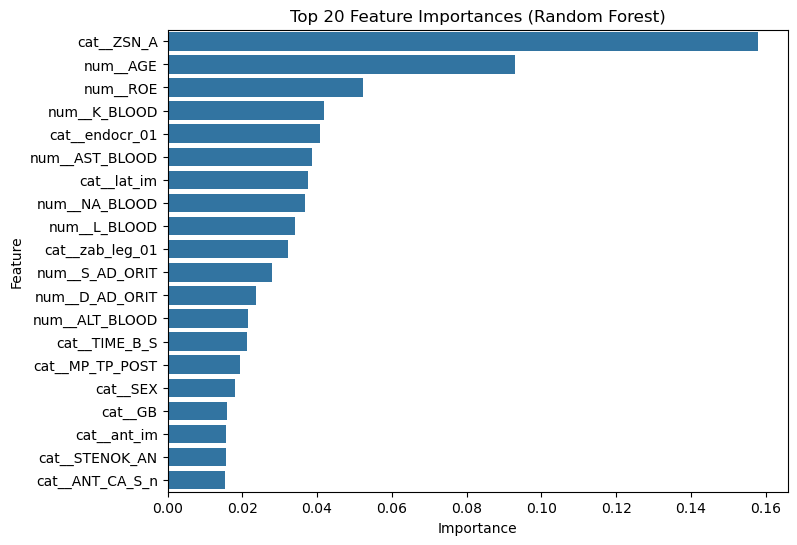

In [564]:
top_features = feature_importance.head(20)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

These features contribute most strongly to the model’s predictions.

Important note:

Feature importance does not necessarily indicate causality.
Highly ranked variables simply help the model distinguish between
patients with and without the outcome.

## Discussion

Questions to consider:

- Which model performed best?
- Which features were most important?
- Are these findings clinically plausible?
- What additional data could improve predictions?